# Object detection on old maps


Goal is to detect buildings, both inhabited and un-inhabited from old maps and produce a GIS-layers of existing buildings for separate time-periods.

Further goal is then to analyze how the buildings have survived through the years.


The project was originally created in TensorFlow and Keras in 2023, now ported to pytorch-platform.

In [1]:
# TODO:
# Test Freezing backbone completely (only heads learn)
# Test varying the heads vs. backbone learning-rates: Create systematic testing setup & logging
# Test creating simple CNN-layers / model from scratch and training it


## Create the dataset

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

# Transformations
from torchvision.tv_tensors import BoundingBoxes
import torchvision.transforms.v2 as T

Create the Dataset-class, simple transformation

In [3]:
class ObjectDetectionDataset(Dataset):
    def __init__(self, csv_file, transform=None, image_subset = None):
        self.base_path = "data/images_train/" #
        self.annotations = pd.read_csv(csv_file)
        self.transform = transform

        # Group annotations by image as there are 0-n boxes per image
        self.image_groups = self.annotations.groupby("filename")

        # Unique image paths
        # NOTE: use only pre-defined-subset of the image-paths; this enables the use of train-eval split
        all_image_paths = list(self.image_groups.groups.keys())
        if image_subset is not None:
            self.image_paths = image_subset
        else:
            self.image_paths = all_image_paths

    def __len__(self): # Returns the length of the IMAGES in dataset, not boxes
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path =  self.image_paths[idx]

        # Note: take all the rows per each image, so there is no leakage between test and train.
        rows = self.image_groups.get_group(image_path) # Get all bboxes for image

        # Load image
        image = Image.open(self.base_path + image_path).convert("RGB")

        # Create lists to store the boxes and their labels
        boxes = []
        labels = []

        for _, row in rows.iterrows():
            boxes.append([
                row["xmin"],
                row["ymin"],
                row["xmax"],
                row["ymax"]
            ])
            labels.append(row["class_num"])

        # Operate based on if boxes on image:
        if len(boxes)==0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0, ), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        # Create target:
        target = {"boxes": boxes, "labels": labels}

        # Convert to BoundingBox format to use the box-aware transforms.v2 -library
        target["boxes"] = BoundingBoxes(target["boxes"],
                                        format = "XYXY",
                                        canvas_size=image.size[::1]
                                        )

        if self.transform:
            image, target = self.transform(image, target)

        return image, target

In [4]:

# OLD-transforms
# Simple transformation, i.e. converting to tensor. 
# transform = transforms.Compose([
#     transforms.ToTensor(),  # Converts to [0,1] and CHW
#     # TODO: Placeholder for image augmentation; Note that only non-position-changing (brightness, colors etc) can be used easily
# ])

In [5]:
# Trasforms for training; NOTE: ToImage + ToDtype replaces ToTensor in this new version
train_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    T.RandomAutocontrast(p=0.5)
])

# validation transforms; this only converts images to tensor, no augmentations
val_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

Create the datasets

In [6]:
# Read first the full dataset; this will be split to eval and train later
full_dataset = ObjectDetectionDataset(
    csv_file="data/train_256px_annotations_extended_cleaned_2026.csv",
    transform=train_transforms
)

In [7]:
# Create the train-eval split
import random

# SEt seed for reprod.
random.seed(123)

# Get all images, suffle and take split.
all_images = full_dataset.image_paths.copy()
random.shuffle(all_images)
split_idx = int(0.8 * len(all_images))

train_images = all_images[:split_idx]
val_images = all_images[split_idx:]

In [8]:
train_dataset = ObjectDetectionDataset(
    csv_file="data/train_256px_annotations_extended_cleaned_2026.csv",
    transform=train_transforms,
    image_subset = train_images
)

val_dataset = ObjectDetectionDataset(
    csv_file="data/train_256px_annotations_extended_cleaned_2026.csv",
    transform = val_transforms,
    image_subset = val_images
)

Create the dataloaders for both eval and train

In [9]:
# Custom collate function; it is needed for varying lenght data, to transform the list into batch (tuple) of standard size
# Here there might be different number of boxes per image, i.e. need to package into same size with collate_fn
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

### Test the dataloader


- Test shape of the outputs
- Test augmentations

In [10]:
# Shape of the outputs
temp_images, temp_targets = next(iter(train_dataloader))

# Print some example data
print(temp_images[5].shape) # RGB image; 3 x 256 x 256
print(temp_targets[5]['boxes']) # boxes; coords and some metadata
print(temp_targets[5]['labels']) # which classes boxes are

torch.Size([3, 256, 256])
BoundingBoxes([[ 79., 207.,  94., 222.],
               [ 93., 156., 111., 172.]], format=BoundingBoxFormat.XYXY, canvas_size=(256, 256), clamping_mode=soft)
tensor([1, 1])


In [11]:
# Helper funcs to plot augmented results

import matplotlib.pyplot as plt
import matplotlib.patches as patches


def draw_boxes(ax, boxes, labels=None, labels_digits = 0, color="lime", linewidth = 2, line_alpha = 1):
    """
    ax     : matplotlib axis
    boxes  : Tensor[N, 4] in XYXY format
    labels : optional Tensor[N]
    """
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1),
            w,
            h,
            linewidth=linewidth,
            edgecolor=color,
            facecolor="none",
            alpha = line_alpha
        )
        ax.add_patch(rect)

        if labels is not None:
            # decide the number of digits shown; for labels, this is 0, for scores, it is 2 digits
            if labels_digits == 0:
                labels_text = str(int(labels[i]))
            else:
                labels_text = f"{labels[i]:.{labels_digits}f}"
            ax.text(
                x1,
                y1 - 3,
                labels_text,
                color=color,
                fontsize=9,
                bbox=dict(facecolor="black", alpha=0.5, pad=1)
            )


def visualize_batch(dataloader, max_images=4):
    images, targets = next(iter(dataloader))

    batch_size = min(len(images), max_images)
    fig, axes = plt.subplots(1, batch_size, figsize=(5 * batch_size, 5))

    if batch_size == 1:
        axes = [axes]

    for i in range(batch_size):
        image = images[i]
        target = targets[i]

        # CHW → HWC
        img_np = image.permute(1, 2, 0).cpu().numpy()

        axes[i].imshow(img_np)
        axes[i].axis("off")

        boxes = target["boxes"]
        labels = target["labels"]

        # BoundingBoxes → Tensor (important)
        if hasattr(boxes, "to_tensor"):
            boxes = boxes.to_tensor()

        if len(boxes) > 0:
            draw_boxes(axes[i], boxes, labels)

    plt.tight_layout()
    plt.show()


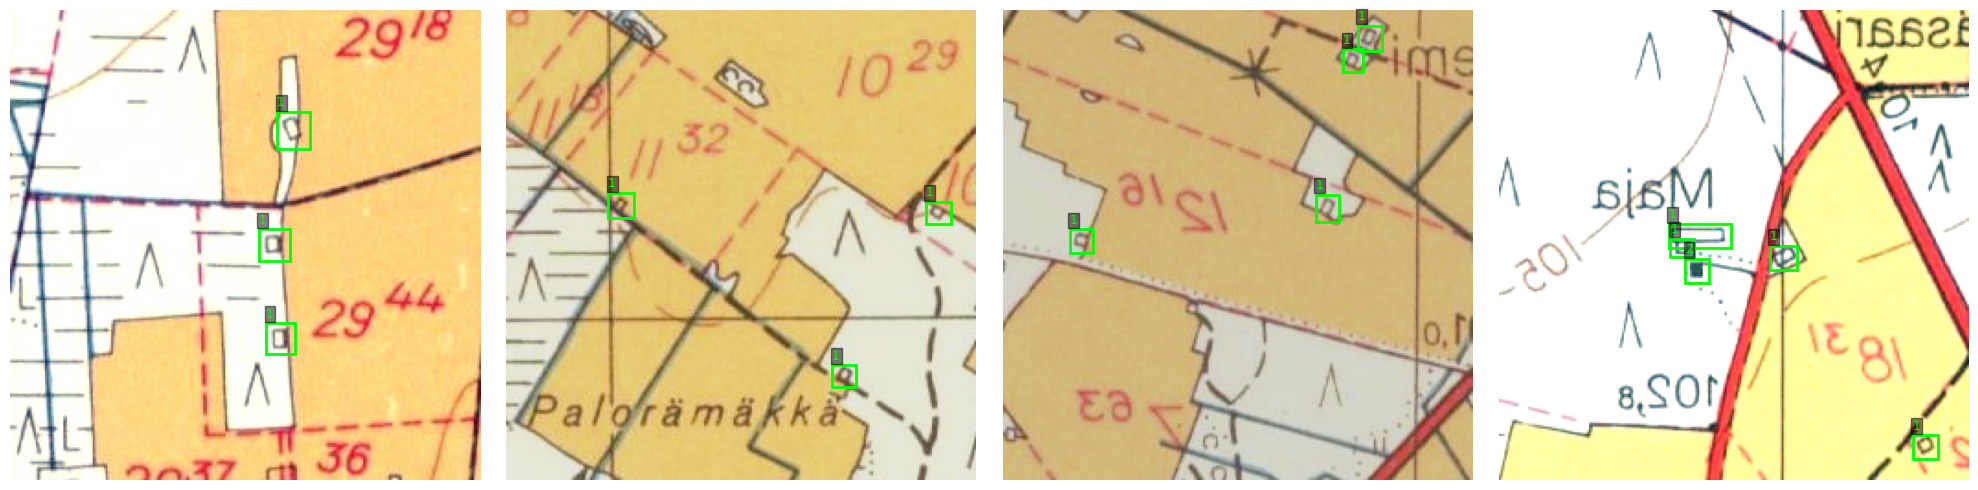

In [12]:
# Augmentations and suffling for training-data:
visualize_batch(train_dataloader, max_images=4)

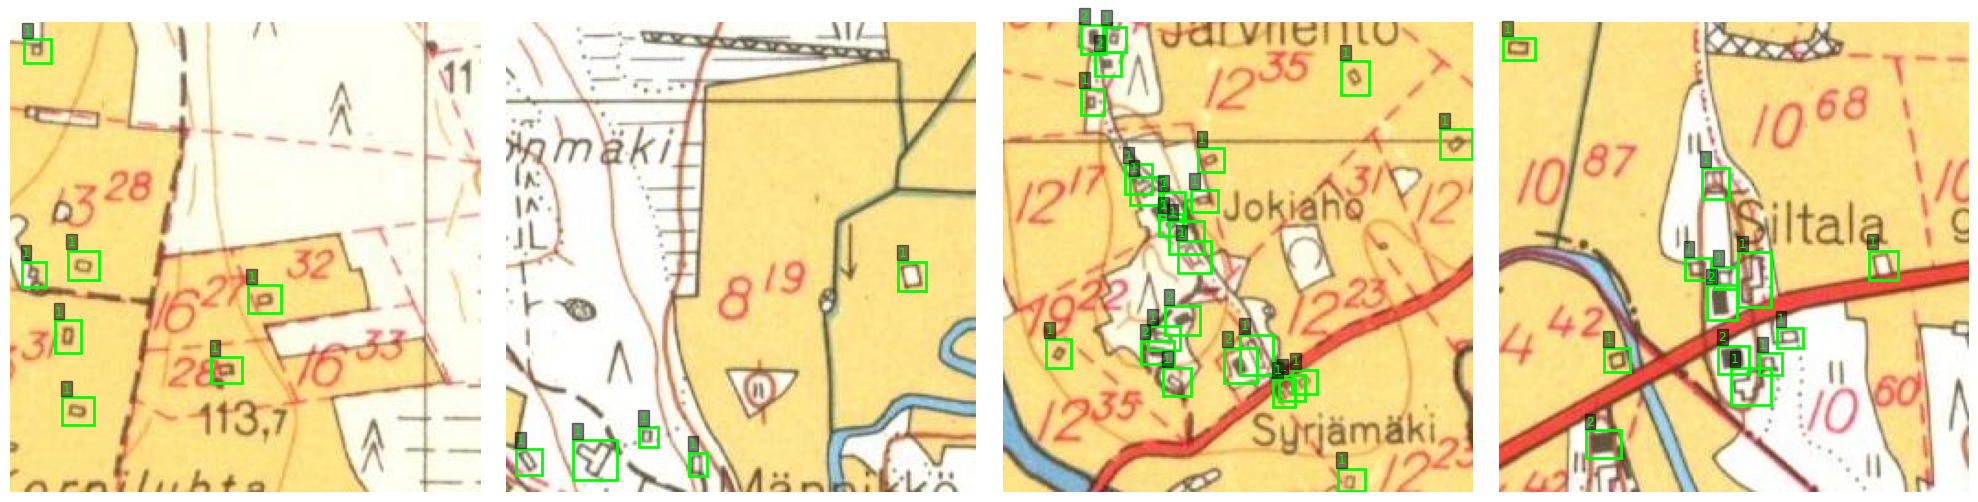

In [87]:
# NOTE: Should NOT have any augmentation or shuffling for validation.
visualize_batch(val_dataloader, max_images=4) 

## Model

In [14]:
# import torchvision.models.detection.fasterrcnn_resnet50_fpn

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead

In [15]:

# model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
#     # pretrained=True, # Deprecated param
#     weights='FasterRCNN_ResNet50_FPN_Weights.DEFAULT',
#     min_size=256,
#     max_size=256
# )

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    # pretrained=True, # Deprecated param
    weights=None,
    min_size=256,
    max_size=256
)

# # Try smaller model to be able to train without messing the deeper layers:
# model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
#     weights_backbone="MobileNet_V3_Large_Weights.DEFAULT",
#     min_size=256,
#     max_size=256,
#     num_classes=3
# )


In [16]:
# # Testing freezing the batch-normalization layers
# NOTE: This should only affect situation if batch-sizes are small (here 64 was used, so not the case....)
# def freeze_bn(module):
#     if isinstance(module, torch.nn.BatchNorm2d):
#         module.eval()
#         for param in module.parameters():
#             param.requires_grad = False

# model.apply(freeze_bn)

### Inspect model params and internals

In [17]:
# Inspect the internal stucture of the model and its params at high level
def print_module_tree(module, prefix=""):
    for name, child in module.named_children():
        print(prefix + name, "→", type(child))
        print_module_tree(child, prefix + "  ")

# print_module_tree(model)

In [18]:
# Detailed view of model params and WHERE they are.

# Looping over all the params of the model: 
# NOTE: Tested and Level 4 is irrelavant; they are methods for converting the inputs from float, nominators etc.
# Use only the level 3
model_param_list = []

for attr_l1 in dir(model):
    for attr_l2 in dir(getattr(model, attr_l1)):
        attr_l3 = dir(getattr(getattr(model, attr_l1), attr_l2))
        model_param_list.append(pd.DataFrame({'L1': attr_l1, 'L2': attr_l2, 'L3': attr_l3}))


# for attr_l1 in dir(model):
#     for attr_l2 in dir(getattr(model, attr_l1)):
#         for attr_l3 in dir(getattr(getattr(model, attr_l1), attr_l2)):
#             print(attr_l1, attr_l2, attr_l3)
#             try:
#                 attr_l4 = dir(getattr(getattr(getattr(model, attr_l1), attr_l2), attr_l3))
#             except:
#                 attr_l4 = ["no_attributes"]
#             model_param_list.append(pd.DataFrame({'L1': attr_l1, 'L2': attr_l2, 'L3': attr_l3, 'L4': attr_l4}))

# Combine and filter out internal params starting with underscore
model_param_list_df = pd.concat(model_param_list, ignore_index = True)
model_param_list_df2 = model_param_list_df[(~model_param_list_df.L1.str.startswith("_"))&(~model_param_list_df.L2.str.startswith("_"))&(~model_param_list_df.L3.str.startswith("_"))].copy()

# Create one additional column for easy string-searching
model_param_list_df2['L123'] = model_param_list_df2['L1'] + '.' + model_param_list_df2['L2'] + '.' + model_param_list_df2['L3']

In [19]:
# NOTE:
# Many similar params exists at level L3 between L1-modules roi_heads and rpn. rpn is the first step in the journey,
# and therefore needs to be tuned first
# RPN = Region Proposal Network: "Where any of the objects are" (Coarse regions of potential candidates for deeper inspection)
# ROI_Heads: Region Of Interest: "Where exactly and what are the objects (classification + finetuning box coords)"

model_param_list_df2[model_param_list_df2.L123.str.contains("batch_size_per_image")]



,L1,L2,L3,L123
141431,roi_heads,fg_bg_sampler,batch_size_per_image,roi_heads.fg_bg_sampler.batch_size_per_image
146446,rpn,fg_bg_sampler,batch_size_per_image,rpn.fg_bg_sampler.batch_size_per_image


In [20]:
# TODO: Search all the relevant runable params and get their names and locations + default-values

### Adjust model parameters to the current case


Customize the number of classes and create a new box-predictor-head with updated number of classes

In [21]:
# model.roi_heads.box_predictor # Predict the classes and bbox-coordinates, so output for cls is 3 and bbox 3 * 4 coords (12)
num_classes = 3  # background + 2 object classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

Parameter tuning - need to customize for the small objects, as they are only covering 1% of the image-area.

In [22]:
# ROI-head customization:
# 1) Take much smaller sample; it only takes whatever positive samples (targets) are in image, then fills the rest with negatives!! Medium number of bboxs per image is 4, max is 40
# 2) Positive fraction is the MAX fraction to take in
# 3) post_nms_top_n is the overall top-k proposals passed on to the ROI-head (from RPN); this can also be limited from default 2000.
model.roi_heads.fg_bg_sampler.batch_size_per_image = 64 # Expecting 4:60 ratio on avg, i.e. 6.25%. (was 4:508, i.e. 0.8%)
model.roi_heads.fg_bg_sampler.positive_fraction = 0.5
# Limit the overall number of proposals to smaller number
model.rpn._post_nms_top_n['training'] = 256 # send 512 best proposals to roi-head


In [23]:
# Examine the number of Pyramid-levels in FPN by printing the model backbone:
# This is needed for the anchors as each pyramid-level needs to have the sizes & aspect_ratios specified
print(model.backbone)
# --> 4 conv2d layers (inner_block) (5th is just a smoothing operation), 
# and 6TH LAYER is max-pooling, which is the 5th real layer

BackboneWithFPN(
  (body): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): FrozenBatchNorm2d(64, eps=1e-05)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): FrozenBatchNorm2d(64, eps=1e-05)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): FrozenBatchNorm2d(64, eps=1e-05)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): FrozenBatchNorm2d(256, eps=1e-05)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): FrozenBatchNorm2d(256, eps=1e-05)
        )
      )
      (1): Bottleneck(
        

In [24]:
model.rpn.anchor_generator.sizes

((32,), (64,), (128,), (256,), (512,))

In [25]:
# # Anchor generator for the MOBBILENET v3 backbone; it has only 3 FPN-lauers:
# anchor_generator = AnchorGenerator(
#     sizes=((12,),
#            (16,),
#            (20,),),  # MUCH smaller than defaults; note that these are taken from EDA
#     aspect_ratios=((0.83, 0.92, 1.1),
#                    (0.82, 0.94, 1.12),
#                    (0.81, 0.95, 1.12),)
# )

In [26]:
# Anchor generator for the ResNet50 backbone; it has 5 FPN-lauers:
# Adjust the generator to much smaller anchors; default sizes are 32, 64, 128, 256, 512
anchor_generator = AnchorGenerator(
    sizes=((10,),
           (12,),
           (16,),
           (20,),
           (28,),),  # MUCH smaller than defaults; note that these are taken from EDA
    aspect_ratios=((0.82, 1.0, 1.1),  # NOTE: Added per-size-ratios from eda-notebook: These follow the 20p / 50p / 80p quantiles.
                   (0.83, 0.92, 1.1),
                   (0.82, 0.94, 1.12),
                   (0.81, 0.95, 1.12),
                   (0.93, 1.05, 1.25),)
)

In [27]:
model.rpn.anchor_generator = anchor_generator

In [28]:
# NOTE:If the above is different from default (3 anchors per location) change the RPN-head, as it expects the basic 1 sizes x 3 aspect-ratios (3 anchors) per each pyramic level
print(anchor_generator.num_anchors_per_location())

# model.rpn.head = RPNHead(
#     in_channels=256,  # FPN output channels
#     num_anchors=anchor_generator.num_anchors_per_location()
# )

[3, 3, 3, 3, 3]


In [29]:
# Treshold for the detection; these are IoU-ratios (Intersection over Union, i.e. how 
# much of the areas overlap between model-proposed vs. ground-truth training-labels)

# High-limit; only higher than these are passed on as correct anchors for training.
# Settng here very high limit, as the objects are completely "wrong" if the overlap is too small and part is cut out.
# Chat-GPT suggestested this to be LOWER to allow for multiple positive matches....
model.rpn.proposal_matcher.high_threshold = 0.7 # defaults to 0.7; higher than this are consider good matches

# Low limit; lower than this are background
model.rpn.proposal_matcher.low_threshold # defaults to 0.3; LOWER than this are consider background, i.e. 

0.3

In [30]:
# How many samples per image? If objects are relatively rare (i.e. most is background), this should be incresed
# dir(model.rpn.fg_bg_sampler) # Contains variables 'batch_size_per_image' and 'positive_fraction'

model.rpn.fg_bg_sampler.batch_size_per_image = 256 # defaults to 256 samples
model.rpn.fg_bg_sampler.positive_fraction # defaults to 0.5


0.5

In [31]:
# Region-Of-Interest (ROI): Finetuning the anchored area:
# Setting to lower increases number of detections --> lift later to reduce false positives
# model.roi_heads.score_thresh # defaults to 0.05
# model.roi_heads.score_thresh = 0.3

In [32]:
# Non-maximum-supression (nms): How much overlap is tolerated? Lower means clustered objects are outputted as single
# model.roi_heads.nms_thresh # def 0.5
# model.roi_heads.nms_thresh = 0.5

In [33]:
# How many objects to detect from image?
model.roi_heads.detections_per_img # defaults to 100
# model.roi_heads.detections_per_img = 100

100

### Move model to device

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Model ready on device:", device)

Model ready on device: cuda


In [35]:
# NOTE: Old, simple version with shared optimizer for both backbone and the heads

# params = [p for p in model.parameters() if p.requires_grad]

# optimizer = torch.optim.SGD(
#     params,
#     lr = 0.005,
#     momentum=0.9,
#     weight_decay=0.0005
# )

# lr_scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size = 5,
#     gamma = 0.1
# )

In [36]:
# Use differential learning rates for the backbone and the detection heads:
backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
head_params = [p for p in model.rpn.parameters() if p.requires_grad] + [p for p in model.roi_heads.parameters() if p.requires_grad]

# optimizer = torch.optim.SGD([
#     {"params": backbone_params, "lr": 0.0002},   # Orig 0.0001; Low LR for pretrained backbone
#     {"params": head_params, "lr": 0.001}          # Higher LR for detection head
# ], 
# momentum=0.9, 
# weight_decay=0.0005
# )

optimizer = torch.optim.Adam([
    {"params": backbone_params, "lr": 0.0002},   # Orig 0.0001; Low LR for pretrained backbone
    {"params": head_params, "lr": 0.001}          # Higher LR for detection head
]
)


# NOTE: If using lr-scheduler, need to uncomment it from the training loop!
# lr_scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size = 15,
#     gamma = 0.95
# )

In [37]:

# TODO: Find out how the below could work, i.e. how to REcreate the optimizer with separate params for head and backbone later....
# Also can try to freeze the backbone for first N epochs (10), then unfreeze and continu e with lower LR

# # Create optimizer with only for head + Freeze backbone

# for p in model.backbone.parameters():
#     p.requires_grad = False

# # ... train for 10 epochs (only head learns) ...

# # Then unfreeze and set up differential LR
# for p in model.backbone.parameters():
#     p.requires_grad = True


# # Recreate optimizer with both groups at this point

# optimizer = torch.optim.SGD([
#     {"params": backbone_params, "lr": 0.0001},   # Low LR for pretrained backbone
#     {"params": head_params, "lr": 0.005}          # Higher LR for detection head
# ], 
# momentum=0.9, 
# weight_decay=0.0005
# )

## Train

In [38]:
# Meta params
plt.ion() # Interactive mode for plotting is on

num_epochs = 100

train_losses = []
val_losses = []

Epoch1/100, train: 1.0011, val: 1.0412


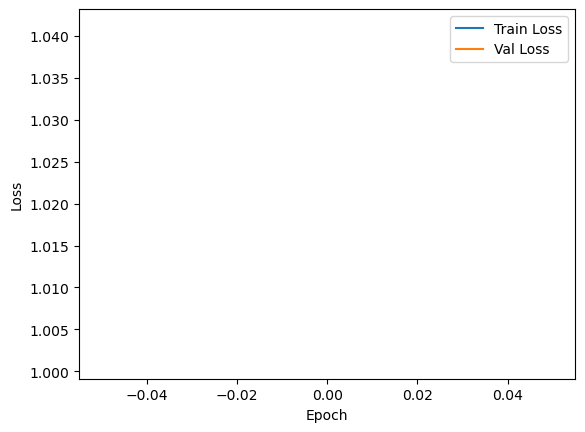

Epoch2/100, train: 1.0169, val: 0.9369
Epoch3/100, train: 0.9205, val: 0.9176
Epoch4/100, train: 0.8697, val: 0.8950
Epoch5/100, train: 0.8370, val: 0.8600
Epoch6/100, train: 0.7939, val: 0.8324
Epoch7/100, train: 0.7905, val: 0.8445
Epoch8/100, train: 0.7875, val: 0.8366
Epoch9/100, train: 0.7500, val: 0.8151
Epoch10/100, train: 0.7424, val: 0.8544
Epoch11/100, train: 0.7208, val: 0.7615


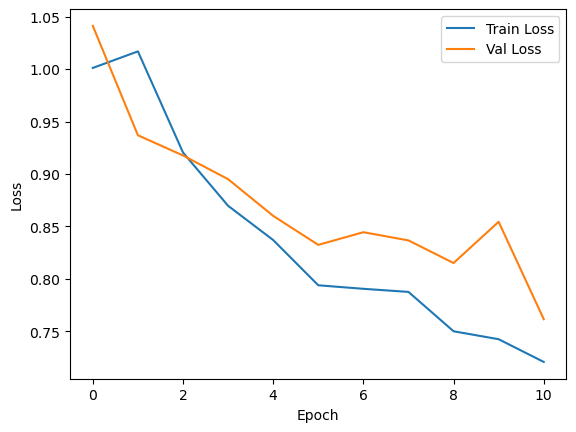

Epoch12/100, train: 0.7213, val: 0.8009
Epoch13/100, train: 0.7180, val: 0.7881
Epoch14/100, train: 0.6946, val: 0.7789
Epoch15/100, train: 0.6939, val: 0.8012
Epoch16/100, train: 0.6755, val: 0.7969
Epoch17/100, train: 0.6607, val: 0.7370
Epoch18/100, train: 0.6483, val: 0.7582
Epoch19/100, train: 0.6690, val: 0.7599
Epoch20/100, train: 0.6416, val: 0.7335
Epoch21/100, train: 0.6336, val: 0.7877


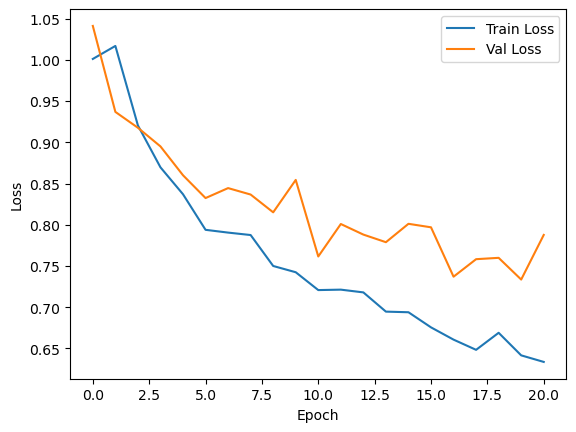

Epoch22/100, train: 0.6312, val: 0.7517
Epoch23/100, train: 0.6257, val: 0.7390
Epoch24/100, train: 0.6143, val: 0.7531
Epoch25/100, train: 0.6023, val: 0.7982
Epoch26/100, train: 0.6047, val: 0.7366
Epoch27/100, train: 0.5905, val: 0.7262
Epoch28/100, train: 0.5796, val: 0.7488
Epoch29/100, train: 0.5768, val: 0.7477
Epoch30/100, train: 0.5520, val: 0.7406
Epoch31/100, train: 0.5494, val: 0.7540


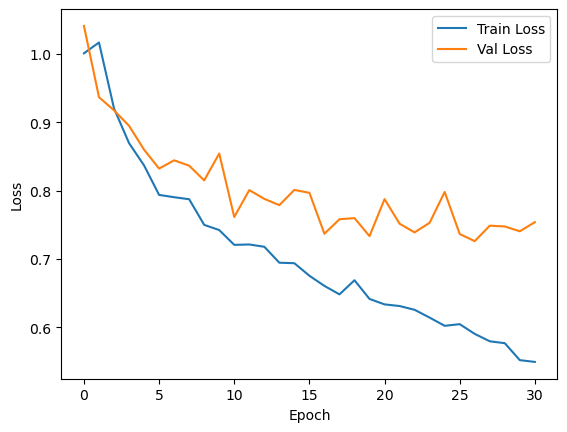

Epoch32/100, train: 0.5459, val: 0.7238
Epoch33/100, train: 0.5280, val: 0.7744
Epoch34/100, train: 0.5316, val: 0.7412
Epoch35/100, train: 0.5090, val: 0.7206
Epoch36/100, train: 0.5141, val: 0.7313
Epoch37/100, train: 0.5103, val: 0.7264
Epoch38/100, train: 0.4950, val: 0.7409
Epoch39/100, train: 0.4835, val: 0.7194
Epoch40/100, train: 0.4815, val: 0.7260
Epoch41/100, train: 0.4917, val: 0.7509


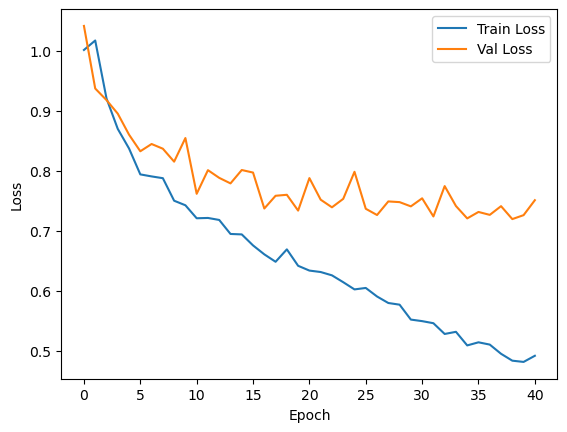

Epoch42/100, train: 0.4739, val: 0.7075
Epoch43/100, train: 0.4688, val: 0.7247
Epoch44/100, train: 0.4625, val: 0.7279
Epoch45/100, train: 0.4630, val: 0.7369
Epoch46/100, train: 0.4406, val: 0.7482
Epoch47/100, train: 0.4399, val: 0.7403
Epoch48/100, train: 0.4367, val: 0.7311
Epoch49/100, train: 0.4212, val: 0.8280
Epoch50/100, train: 0.4293, val: 0.6981
Epoch51/100, train: 0.4061, val: 0.7040


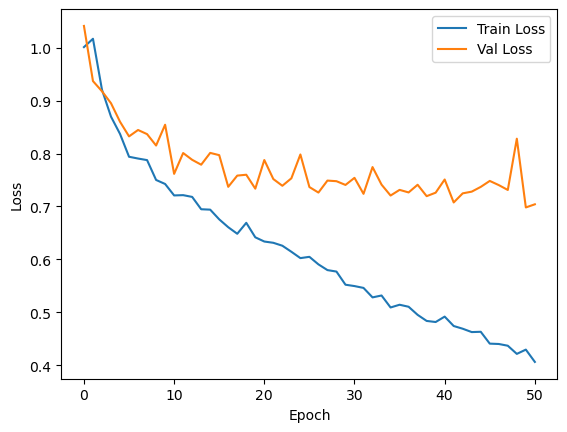

Epoch52/100, train: 0.4018, val: 0.7157
Epoch53/100, train: 0.4023, val: 0.7281
Epoch54/100, train: 0.4020, val: 0.6464
Epoch55/100, train: 0.3968, val: 0.7148
Epoch56/100, train: 0.4024, val: 0.7314
Epoch57/100, train: 0.3936, val: 0.7554
Epoch58/100, train: 0.3850, val: 0.7491
Epoch59/100, train: 0.3813, val: 0.7335
Epoch60/100, train: 0.3803, val: 0.7568
Epoch61/100, train: 0.3868, val: 0.7585


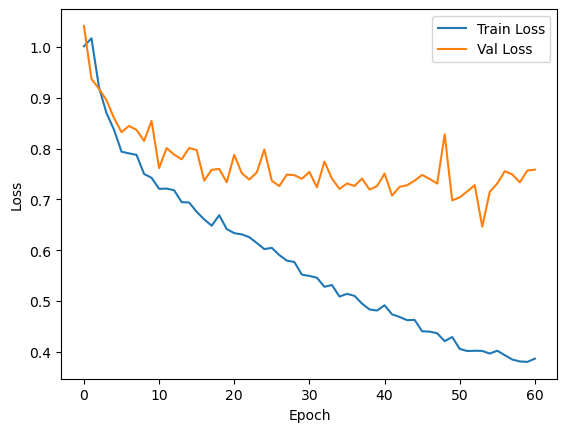

Epoch62/100, train: 0.3762, val: 0.7758
Epoch63/100, train: 0.3747, val: 0.6725
Epoch64/100, train: 0.3611, val: 0.7236
Epoch65/100, train: 0.3542, val: 0.7201
Epoch66/100, train: 0.3544, val: 0.7566
Epoch67/100, train: 0.3600, val: 0.7046
Epoch68/100, train: 0.3394, val: 0.7424
Epoch69/100, train: 0.3480, val: 0.7539
Epoch70/100, train: 0.3504, val: 0.7680
Epoch71/100, train: 0.3473, val: 0.7505


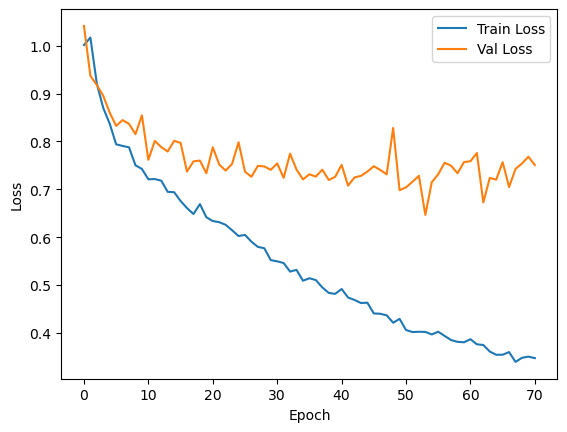

Epoch72/100, train: 0.3405, val: 0.7790
Epoch73/100, train: 0.3439, val: 0.7181
Epoch74/100, train: 0.3196, val: 0.7422
Epoch75/100, train: 0.3392, val: 0.7565
Epoch76/100, train: 0.3426, val: 0.7419
Epoch77/100, train: 0.3307, val: 0.7383
Epoch78/100, train: 0.3264, val: 0.6913
Epoch79/100, train: 0.3197, val: 0.7057
Epoch80/100, train: 0.3147, val: 0.7170
Epoch81/100, train: 0.3121, val: 0.7981


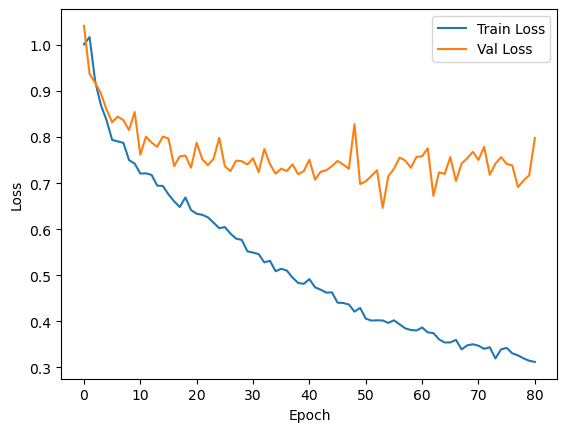

Epoch82/100, train: 0.3229, val: 0.7758
Epoch83/100, train: 0.3159, val: 0.7367
Epoch84/100, train: 0.3050, val: 0.7401
Epoch85/100, train: 0.2995, val: 0.7225
Epoch86/100, train: 0.2942, val: 0.7378
Epoch87/100, train: 0.2844, val: 0.7414
Epoch88/100, train: 0.2999, val: 0.7614
Epoch89/100, train: 0.2861, val: 0.7329
Epoch90/100, train: 0.2927, val: 0.7312
Epoch91/100, train: 0.2869, val: 0.7381


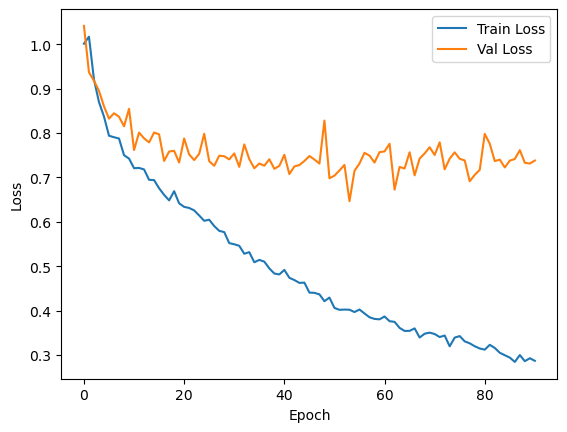

Epoch92/100, train: 0.3007, val: 0.7064
Epoch93/100, train: 0.2903, val: 0.7537
Epoch94/100, train: 0.2760, val: 0.7533
Epoch95/100, train: 0.2792, val: 0.7509
Epoch96/100, train: 0.2854, val: 0.7693
Epoch97/100, train: 0.2716, val: 0.7584
Epoch98/100, train: 0.3003, val: 0.7555
Epoch99/100, train: 0.2850, val: 0.7747
Epoch100/100, train: 0.2713, val: 0.7054
Epoch101/100, train: 0.2656, val: 0.7733


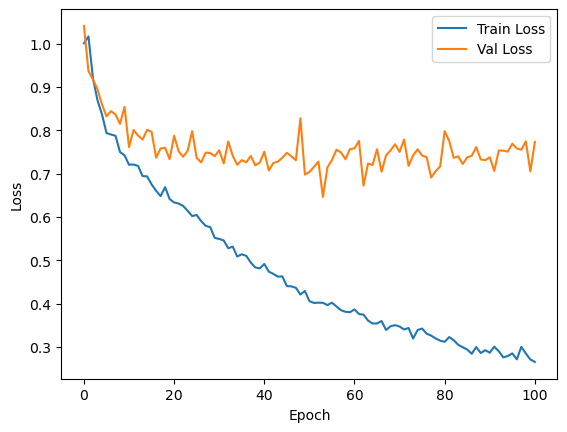

In [39]:
for epoch in range(num_epochs + 1):

    # ----------------  Training ----------------
    model.train()
    epoch_train_loss = 0

    # Get all images and targets in dataloader
    for images, targets in train_dataloader:

        # Send images to device
        images = [img.to(device) for img in images]

        # Send targets to device; 
        # note, only sends the 'key: value' -dictionaries
        targets = [
            {k: v.to(device) for k, v in t.items()} for t in targets
        ]

        # Forward pass:
        # Get the loss from model and sum
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Temporary debugging, print the loss dict; if loss_objectness is small and/or the loss_rpn_box_reg is very small the RPN is not learning
        # print(loss_dict)

        # Backward pass;
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Get the total loss for training epoch
        epoch_train_loss += losses.item()

    # Get the average loss per image
    epoch_train_loss /= len(train_dataloader)
    train_losses.append(epoch_train_loss)

    # After epoch is ready, advance the learning-rate-scheduler by one step
    # lr_scheduler.step()

    # ------------------ Validation --------------------
    model.train() # NOTE: Keep in train-model to get the loss (only available in train)
    epoch_val_loss = 0

    with torch.no_grad():
        for images, targets in val_dataloader:
            images = [img.to(device) for img in images]
            targets = [
                {k: v.to(device) for k, v in t.items()} for t in targets
            ]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            epoch_val_loss += losses.item()

    epoch_val_loss /= len(val_dataloader)
    val_losses.append(epoch_val_loss)

    # -------------- Debugging   -------------------- # TODO: Added this section from ChatGPT
    # with torch.no_grad():
    #     images_transformed, targets_transformed = model.transform(images, targets)
    #     features = model.backbone(images_transformed.tensors)
    #     if isinstance(features, torch.Tensor):
    #         features = {"0": features}

    #     proposals, _ = model.rpn(images_transformed, features, targets_transformed)

    #     # Assign GT to proposals
    #     # assign_target_to_proposals(self, proposals, gt_boxes, gt_labels)# Returns: labels, matched_boxes
    #     matched_idxs, labels = model.roi_heads.assign_targets_to_proposals(
    #         proposals, targets_transformed
    #     )

    #     for i, lbl in enumerate(labels):
    #         num_pos = (lbl > 0).sum().item()
    #         num_neg = (lbl == 0).sum().item()
    #         print(f"Image {i}: positives={num_pos}, negatives={num_neg}")

    # ------------  Stats  ---------------------
    # Print the stats for each epoch
    print(f"Epoch{epoch+1}/{num_epochs}, train: {epoch_train_loss:.4f}, val: {epoch_val_loss:.4f}")

    if epoch % 10 == 0:
        # Plot
        plt.clf()
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.pause(0.01)


In [40]:
# Temporary debugging: Plot the matched boxes and if they are correct
with torch.no_grad():
    images_transformed, targets_transformed = model.transform(images, targets)
    features = model.backbone(images_transformed.tensors)
    if isinstance(features, torch.Tensor):
        features = {"0": features}

    proposals, _ = model.rpn(images_transformed, features, targets_transformed)
    targets_transformed_boxes = [i['boxes'] for i in targets_transformed]
    targets_transformed_labels = [i['labels'] for i in targets_transformed]
    matched_idxs, labels = model.roi_heads.assign_targets_to_proposals(
        proposals, targets_transformed_boxes, targets_transformed_labels
    )


In [72]:
# NEW version that should predict for all images in validation set
# After training, do evaluation-predicitons
# Set the model to evaluation mode; omits the dropout etc.
model.eval()
all_test_outputs = []

with torch.no_grad():
    for images, targets in val_dataloader:
        images = [img.to(device) for img in images]
        batch_outputs = model(images)

        # Move tensors to CPU and store per-image dicts
        cpu_batch = []
        for out in batch_outputs:
            cpu_batch.append({k: v.cpu() if isinstance(v, torch.Tensor) else v for k, v in out.items()})
        all_test_outputs.extend(cpu_batch)

# all_test_outputs should have one entry per validation image
len(all_test_outputs)
# ...existing code...

260

In [ ]:
# # After training, do evaluation-predicitons
# # Set the model to evaluation mode; omits the dropout etc.
# model.eval()

# # Output is list of dicts: each list-element is for one image in validation data. dict_keys(['boxes', 'labels', 'scores'])
# with torch.no_grad():
#     for images, targets in val_dataloader:
#         print(targets)
#         images = [img.to(device) for img in images]
#         test_outputs = model(images)
#         # TODO: calculate success metrics lie mAP, IoU, precision and recall

({'boxes': BoundingBoxes([[  7.,   9.,  22.,  22.],
               [ 31., 124.,  48., 140.],
               [129., 143., 147., 158.],
               [109., 182., 126., 196.],
               [ 24., 162.,  38., 180.],
               [  6., 130.,  19., 144.],
               [ 28., 204.,  45., 219.]], format=BoundingBoxFormat.XYXY, canvas_size=(256, 256), clamping_mode=soft), 'labels': tensor([1, 1, 1, 1, 1, 1, 1])}, {'boxes': BoundingBoxes([[213., 130., 228., 146.],
               [  5., 232.,  19., 246.],
               [ 72., 220.,  82., 231.],
               [ 99., 234., 109., 247.],
               [ 36., 227.,  60., 249.]], format=BoundingBoxFormat.XYXY, canvas_size=(256, 256), clamping_mode=soft), 'labels': tensor([1, 1, 1, 1, 1])}, {'boxes': BoundingBoxes([[ 54.,   2.,  67.,  16.],
               [ 42.,  36.,  55.,  50.],
               [184.,  21., 199.,  39.],
               [106.,  68., 120.,  81.],
               [ 66.,  77.,  81.,  93.],
               [ 69.,  84.,  87.,  99.],

In [92]:
# Function to plot the single image from validation data set
# PLUS the real boxes
# PLUS the predicted boxes, along with the confidences

def plot_predictions(image_idx, val_dataset, predictions, score_filter_treshold = 0.5):
    c_image, c_targets = val_dataset[image_idx]
    c_target_boxes, c_target_labels = c_targets['boxes'], c_targets['labels']

    c_preds = predictions[image_idx]
    c_preds_boxes, c_preds_labels, c_preds_scores = c_preds['boxes'], c_preds['labels'], c_preds['scores']

    fig, axes = plt.subplots(1, 1, figsize = (8, 8))

    # Plot image
    # Channel conversion - needed?
    img_np = c_image.permute(1, 2, 0).cpu().numpy()
    axes.imshow(img_np)

    # Add ground-truth-boxes (convert to tensor)
    if hasattr(c_target_boxes, "to_tensor"):
        c_target_boxes = c_target_boxes.to_tensor()

    if len(c_target_boxes) > 0:
        draw_boxes(axes, c_target_boxes, c_target_labels, color = 'red')

    # Add predictions + confidences
    # Filter by the score to only show the limited number
    c_preds_boxes = c_preds_boxes[c_preds_scores > score_filter_treshold]
    c_preds_labels = c_preds_labels[c_preds_scores > score_filter_treshold]
    c_preds_scores = c_preds_scores[c_preds_scores > score_filter_treshold]

    if len(c_preds_boxes) > 0:
        draw_boxes(ax = axes, boxes = c_preds_boxes, labels = c_preds_scores, labels_digits = 2, color = 'purple')
    
    plt.show()
    

In [43]:
# TODO:
# Get all the eval-images to plot - now only plot the idx 0-3.....
# Test training from scratch without the pre-trained weights (or using pre-trained, but freezing the low-level layers only?)
# Plot in SINGLE image during the training ( use the tensorboard properly to log the graphics)

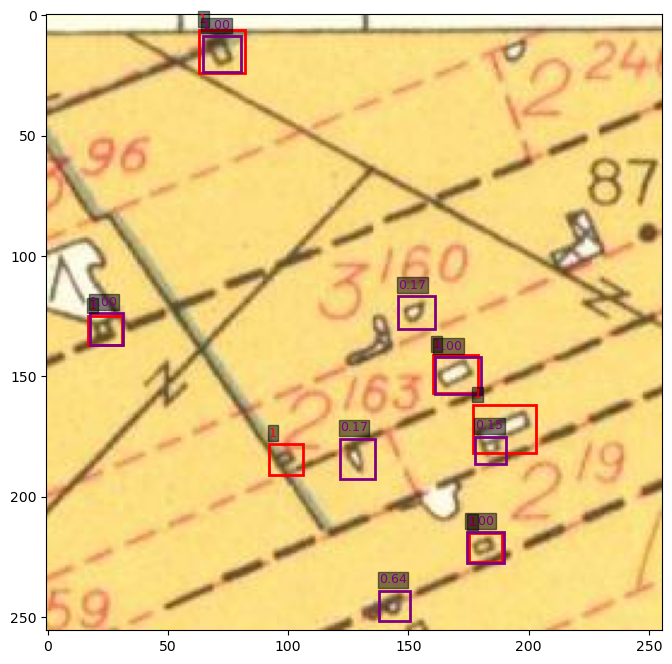

In [93]:
# plot_predictions(image_idx = 2, val_dataset = train_dataset, predictions = test_outputs, score_filter_treshold=0.7)
plot_predictions(image_idx = 259, val_dataset = val_dataset, predictions = all_test_outputs, score_filter_treshold=0.1)

## Prediction testing on completely new data

In [ ]:
# Read completely new image


In [ ]:
plot_predictions(image_idx = 3, val_dataset = train_dataset, predictions = test_outputs, score_filter_treshold=0.7)

### RPN debugging

In [45]:
# Try to get the RPN proposals to check if they are good?

model.eval()

temp_images, temp_targets = next(iter(val_dataloader))

temp_images = [img.to(device) for img in temp_images]
temp_targets = [{k: v.to(device) for k, v in t.items()} for t in temp_targets]

In [46]:
# Transform images (as would be in model)
temp_images_tr, temp_targets_tr = model.transform(temp_images, temp_targets)

In [47]:
# These now contain the images; length is the batch-size (16)
temp_images_tr.tensors
temp_images_tr.image_sizes

[(256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256)]

In [48]:
# Extract the CNN-features manually from the model backbone
temp_features = model.backbone(temp_images_tr.tensors)

# This is dict of length 5, the same as FPN layers (4 x conv + 1 pooling)
# temp_features.keys()

In [49]:
# Run the RPN directly
temp_proposals, temp_proposal_losses = model.rpn(
    temp_images_tr,
    temp_features,
    temp_targets_tr
)

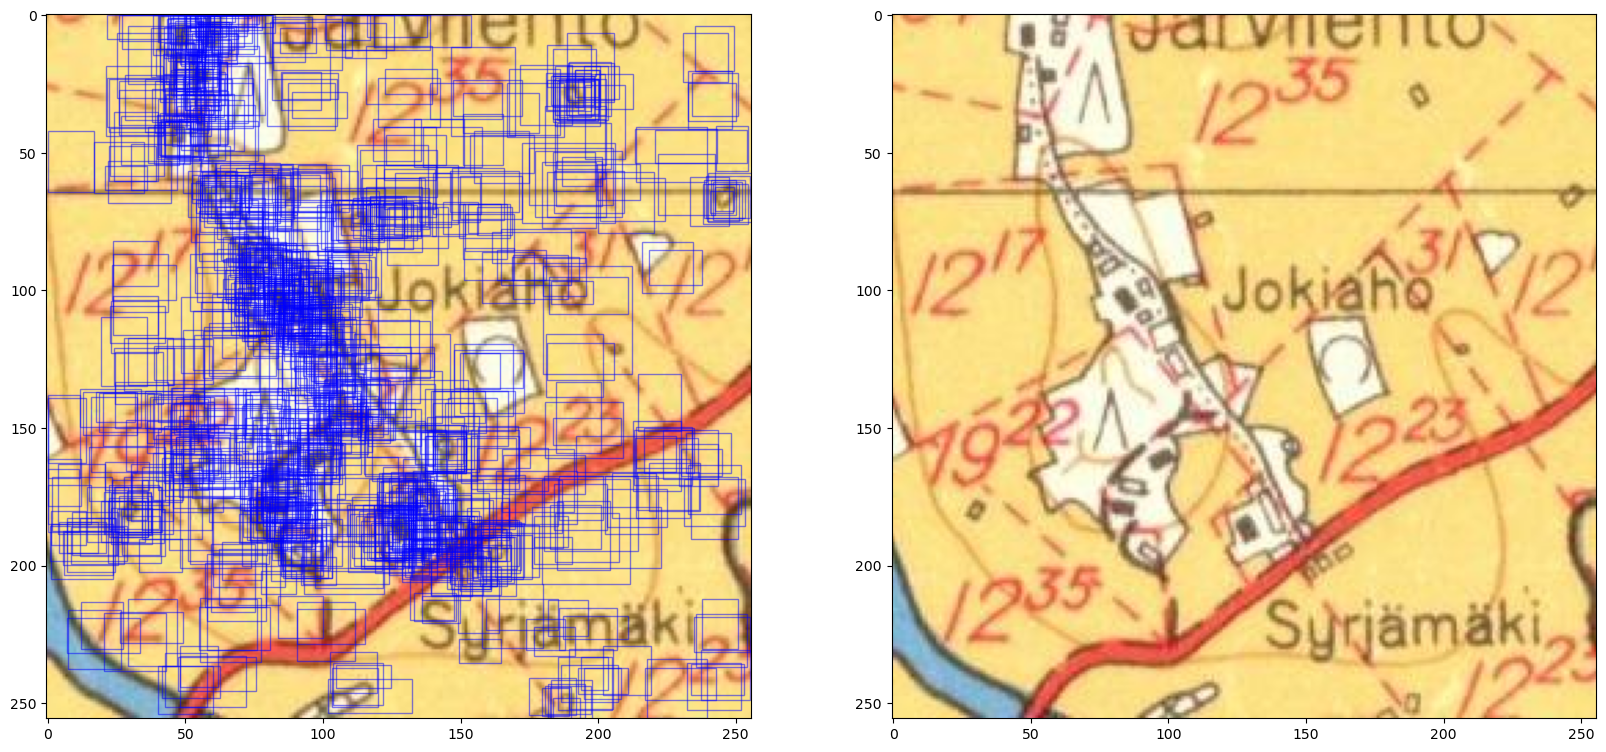

In [50]:
# Visualise the proposals; are they clustering on the true building locations?
# 
img_num = 2
fig, axes = plt.subplots(1, 2, figsize = (20, 20))
axes[0].imshow(temp_images[img_num].permute(1, 2, 0).cpu())
axes[1].imshow(temp_images[img_num].permute(1, 2, 0).cpu())
draw_boxes(axes[0], temp_proposals[img_num], color = 'blue', linewidth = 1, line_alpha = 0.5)
plt.show()